In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [3]:
DATA_DIR = "../../data/raw/"

for split in ["Train", "Test"]:
    print(f"\n📁 {split}:")
    ruta_split = os.path.join(DATA_DIR, split)
    for clase in sorted(os.listdir(ruta_split)):
        ruta_clase = os.path.join(ruta_split, clase)
        if os.path.isdir(ruta_clase):
            n = len(os.listdir(ruta_clase))
            print(f"   {clase}: {n} imágenes")


📁 Train:
   freshapples: 2424 imágenes
   freshbanana: 2468 imágenes
   freshbittergroud: 327 imágenes
   freshcapsicum: 990 imágenes
   freshcucumber: 496 imágenes
   freshokra: 635 imágenes
   freshoranges: 1466 imágenes
   freshpotato: 536 imágenes
   freshtomato: 1858 imágenes
   rottenapples: 3248 imágenes
   rottenbanana: 2932 imágenes
   rottenbittergroud: 357 imágenes
   rottencapsicum: 901 imágenes
   rottencucumber: 421 imágenes
   rottenokra: 338 imágenes
   rottenoranges: 1595 imágenes
   rottenpotato: 802 imágenes
   rottentomato: 1825 imágenes

📁 Test:
   freshapples: 791 imágenes
   freshbanana: 892 imágenes
   freshcucumber: 279 imágenes
   freshokra: 370 imágenes
   freshoranges: 388 imágenes
   freshpatato: 270 imágenes
   freshtamto: 255 imágenes
   rottenapples: 988 imágenes
   rottenbanana: 900 imágenes
   rottencucumber: 255 imágenes
   rottenokra: 224 imágenes
   rottenoranges: 403 imágenes
   rottenpatato: 370 imágenes
   rottentamto: 353 imágenes


IndexError: index 14 is out of bounds for axis 0 with size 14

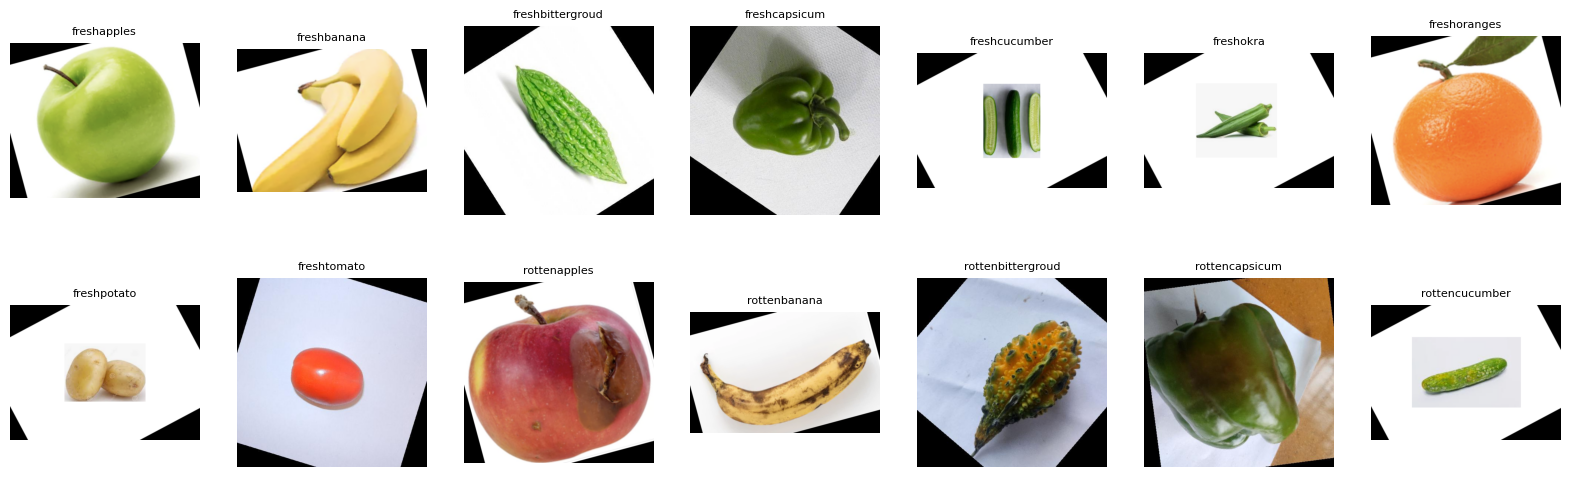

In [4]:
clases_train = sorted(os.listdir(os.path.join(DATA_DIR, "Train")))

fig, axes = plt.subplots(2, 7, figsize=(20, 6))
axes = axes.flatten()

for i, clase in enumerate(clases_train):
    ruta_clase = os.path.join(DATA_DIR, "Train", clase)
    primera_imagen = os.listdir(ruta_clase)[0]
    img = Image.open(os.path.join(ruta_clase, primera_imagen))
    axes[i].imshow(img)
    axes[i].set_title(clase, fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [5]:
# Clases que excluimos por no estar en ambos splits
EXCLUIR = [
    "freshbittergroud", "rottenbittergroud",
    "freshcapsicum", "rottencapsicum"
]

# Función para colapsar el nombre de clase a fresh/rotten
def get_etiqueta(nombre_clase):
    if nombre_clase.startswith("fresh"):
        return "fresh"
    elif nombre_clase.startswith("rotten"):
        return "rotten"
    return None

# Verificar cómo quedan las clases finales
print("Clases finales en Train:")
for clase in sorted(os.listdir(os.path.join(DATA_DIR, "Train"))):
    if clase not in EXCLUIR:
        print(f"   {clase} → {get_etiqueta(clase)}")

Clases finales en Train:
   freshapples → fresh
   freshbanana → fresh
   freshcucumber → fresh
   freshokra → fresh
   freshoranges → fresh
   freshpotato → fresh
   freshtomato → fresh
   rottenapples → rotten
   rottenbanana → rotten
   rottencucumber → rotten
   rottenokra → rotten
   rottenoranges → rotten
   rottenpotato → rotten
   rottentomato → rotten


In [6]:
for split in ["Train", "Test"]:
    conteo = {"fresh": 0, "rotten": 0}
    ruta_split = os.path.join(DATA_DIR, split)
    
    for clase in os.listdir(ruta_split):
        if clase in EXCLUIR:
            continue
        etiqueta = get_etiqueta(clase)
        if etiqueta:
            ruta_clase = os.path.join(ruta_split, clase)
            conteo[etiqueta] += len(os.listdir(ruta_clase))
    
    print(f"\n📁 {split}:")
    print(f"   fresh:  {conteo['fresh']} imágenes")
    print(f"   rotten: {conteo['rotten']} imágenes")
    total = conteo['fresh'] + conteo['rotten']
    print(f"   total:  {total} imágenes")


📁 Train:
   fresh:  9883 imágenes
   rotten: 11161 imágenes
   total:  21044 imágenes

📁 Test:
   fresh:  3245 imágenes
   rotten: 3493 imágenes
   total:  6738 imágenes


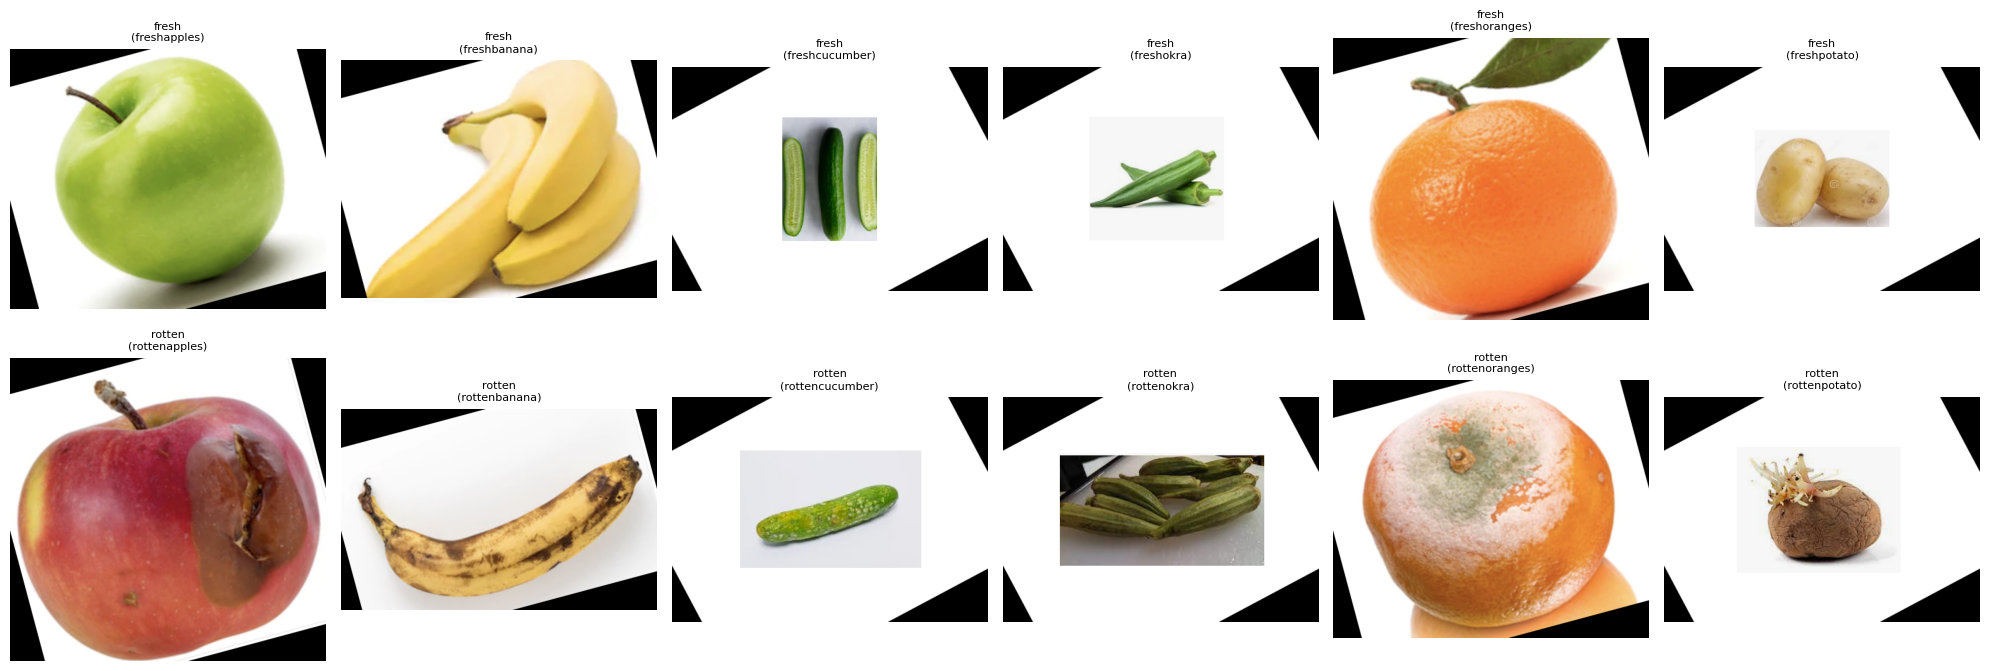

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for row, etiqueta in enumerate(["fresh", "rotten"]):
    ejemplos = []
    for clase in os.listdir(os.path.join(DATA_DIR, "Train")):
        if clase in EXCLUIR:
            continue
        if get_etiqueta(clase) == etiqueta:
            ruta_clase = os.path.join(DATA_DIR, "Train", clase)
            img_path = os.path.join(ruta_clase, os.listdir(ruta_clase)[0])
            ejemplos.append((clase, img_path))
        if len(ejemplos) == 6:
            break

    for col, (clase, img_path) in enumerate(ejemplos):
        img = Image.open(img_path)
        axes[row][col].imshow(img)
        axes[row][col].set_title(f"{etiqueta}\n({clase})", fontsize=8)
        axes[row][col].axis('off')

plt.tight_layout()
plt.show()